In [3]:
import numpy as np, itertools
import tools21cm as t2c, numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

from scipy import special
from scipy import stats
from scipy.optimize import curve_fit
from scipy.special import jn
from scipy.special import jv
from scipy.integrate import quad

from tqdm import tqdm

import astropy.units as u
import astropy.constants as cst
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import Angle

from matplotlib.colors import LogNorm

In [4]:
def galactic_synch_fg_custom(z, ncells, boxsize, rseed=False):
    """
    Simulated synchrotron emission. Simplified because of removed noise.
    """
    if(isinstance(z, float)):
        z = np.array([z])
    else:
        z = np.array(z, copy=False)

    gf_data = np.zeros((ncells, ncells, z.size))

    if(rseed): 
        np.random.seed(rseed)
	
    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))
    nu_s,A150,beta_,a_syn,Da_syn = 150,5.13*1e-4,2.34,2.8,0.1
	
    for i in range(0, z.size):
        nu = t2c.cosmo.z_to_nu(z[i])
        U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z[i])/boxsize
        l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
        C_syn = A150*(1000/l_cb)**beta_
        solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z[i])**2
        AA = np.sqrt(solid_angle*C_syn/2)
        T_four = AA*(X+Y*1j) * np.sqrt(2)
        T_real = np.abs(np.fft.ifft2(T_four))   #in Jansky
        gf_data[..., i]= T_real
        #gf_data[..., i] = t2c.telescope_functions.jansky_2_kelvin(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
        #gf_data[..., i] = t2c.telescope_functions.kelvin_2_jansky(T_real*1e6, z[i], boxsize=boxsize, ncells=ncells)
    
    return gf_data.squeeze(), l_cb

def synchrotron_image(z, ncells, boxsize, seed=False):
    if(seed): 
        np.random.seed(seed)

    X  = np.random.normal(size=(ncells, ncells))
    Y  = np.random.normal(size=(ncells, ncells))

    A150, beta= 5.13*1e-4, 2.34

    U_cb  = (np.mgrid[-ncells/2:ncells/2,-ncells/2:ncells/2]+0.5)*t2c.cosmo.z_to_cdist(z)/boxsize
    l_cb  = 2*np.pi*np.sqrt(U_cb[0,:,:]**2+U_cb[1,:,:]**2)
    C_syn = A150*(1000/l_cb)**beta
    solid_angle = boxsize**2/t2c.cosmo.z_to_cdist(z)**2
    AA = np.sqrt(solid_angle*C_syn/2)
    T_four = AA*(X+Y*1j)  * np.sqrt(2)
    T_real = np.abs(np.fft.ifft2(T_four))

    return T_real, l_cb

def telescope_beam_pattern(x, y, D, z):
    """
    Returns a 2D Gaussian array representing the telescope beam pattern.

    Parameters
    ----------
    x : ndarray
        Meshgrid x-coordinates.
    y : ndarray
        Meshgrid y-coordinates.
    D : float, optional
        Telescope dish diameter, in meters (default is 45).
    z : float, optional
        Redshift, which is converted to observation frequency (default is 7).

    Returns
    -------
    ndarray
        A 2D Gaussian array representing the telescope beam pattern.

    Notes
    -----
    The Gaussian array is calculated based on the provided dish diameter and redshift.
    """
    freq= t2c.cosmo.z_to_nu(z) * 10**6
    lam = cst.c.value / freq
    fwhm= 1.03*lam / D
    theta_0 = 0.6* fwhm
    return np.exp(-((x**2 + y**2) / theta_0**2))

def gaussian_source_2d(x, y, cov):
    """
    Calculate the value of a 2D Gaussian source at given coordinates (x, y).

    Parameters:
    - x (float): x-coordinate of the point.
    - y (float): y-coordinate of the point.
    - cov (list): Covariance matrix in arcseconds.

    Returns:
    - float: Value of the 2D Gaussian source at the given coordinates.

    Notes:
    - The covariance matrix takes two values provided in arcseconds.
    - The mean of the Gaussian source is assumed to be (0, 0).
    """
    mean = np.array([0, 0])  # Mean of the Gaussian source
    cov = np.array([[(cov[0] * u.arcsec).to('rad').value, 0], [0, (cov[1] * u.arcsec).to('rad').value]])
    x_diff = x - mean[0]
    y_diff = y - mean[1]
    inv_cov = np.linalg.inv(cov)
    exponent = -0.5 * (x_diff**2 * inv_cov[0, 0] + y_diff**2 * inv_cov[1, 1] + 2 * x_diff * y_diff * inv_cov[0, 1])
    prefactor = 1 / (2 * np.pi * np.sqrt(np.linalg.det(cov)))

    return prefactor * np.exp(exponent)

def hirax_layout(N_ant, range):
    """
    Generates a square grid layout of antennas, similar to HIRAX.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).

    Returns
    -------
    ndarray
        An array containing the coordinates of the antennas arranged in a square grid.
        Each row represents the (x, y) coordinates of an antenna.
    """
    x= np.linspace(range[0], range[1], int(np.sqrt(N_ant)))
    X, Y= np.meshgrid(x, x)
    return np.dstack((X, Y)).reshape(-1, 2)

def random_layout(N_ant, range, seed):
    """
    Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X= np.random.uniform(range[0], range[1], N_ant)
    Y= np.random.uniform(range[0], range[1], N_ant)

    return np.dstack((X,Y)).reshape(-1, 2)

def random_layout_concentrated(N_ant, range_large, range_small, seed):
    
    np.random.seed(seed)
    # Generate antennas within the larger range
    X_large = np.random.uniform(range_large[0], range_large[1], N_ant)
    Y_large = np.random.uniform(range_large[0], range_large[1], N_ant)
    
    # Generate antennas within the smaller range
    X_small = np.random.uniform(range_small[0], range_small[1], N_ant)
    Y_small = np.random.uniform(range_small[0], range_small[1], N_ant)

    # Concatenate the generated points from both ranges
    X = np.concatenate((X_large, X_small))
    Y = np.concatenate((Y_large, Y_small))

    return np.dstack((X,Y)).reshape(-1, 2)

def random_normal_layout(N_ant, range, seed):
    """
    Generates a random layout of antennas within the specified range.

    Parameters
    ----------
    N_ant : int
        Number of antennas to generate.
    range : tuple
        Tuple specifying the range of coordinates in which antennas will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)
    X= np.random.normal(range[0], range[1], N_ant)
    Y= np.random.normal(range[0], range[1], N_ant)

    return np.dstack((X,Y)).reshape(-1, 2)

def ring_layout(N_ring, N_center, radius_range, center_range, seed):
    """
    Generates a layout of antennas with a specified number of antennas in a ring and within the center.
    Antennas within the center can also be generated using the ring method.

    Parameters
    ----------
    N_ring : int
        Number of antennas to generate in the ring.
    N_center : int
        Number of antennas to generate within the center.
    radius_range : tuple
        Tuple specifying the range of the ring radius.
        It should be in the format (min_radius, max_radius).
    center_range : tuple
        Tuple specifying the range of coordinates in which antennas within the center will be placed.
        It should be in the format (min_value, max_value).
    seed : int
        Seed value for random number generation.

    Returns
    -------
    ndarray
        An array containing the coordinates of the randomly placed antennas.
        Each row represents the (x, y) coordinates of an antenna.
    """

    np.random.seed(seed)

    # Generate antennas in the ring
    theta_ring = np.random.uniform(0, 2*np.pi, N_ring)
    radius_ring = np.random.uniform(radius_range[0], radius_range[1], N_ring)
    X_ring = radius_ring * np.cos(theta_ring)
    Y_ring = radius_ring * np.sin(theta_ring)

    # Generate antennas within the center using the ring method
    theta_center = np.random.uniform(0, 2*np.pi, N_center)
    radius_center = np.random.uniform(0, min(center_range[1], max(radius_range)), N_center)
    X_center = radius_center * np.cos(theta_center)
    Y_center = radius_center * np.sin(theta_center)

    # Combine antennas from ring and center
    X = np.concatenate((X_ring, X_center))
    Y = np.concatenate((Y_ring, Y_center))

    return np.dstack((X,Y)).reshape(-1, 2)

def median_index(list):
    """
    Returns the index of the median value in a numpy list.

    Parameters:
    - list: numpy array or list
        The input array containing numerical values.

    Returns:
    - int
        The index of the element closest to the median value.

    Raises:
    - ValueError: If the input list is empty.
    """
    average = np.mean(list)
    closest_index = np.abs(list - average).argmin()
    return closest_index

def arbitrary_index(list, value):
    """
    Find the index of the closest element in a list to a given value.

    Parameters:
    list (array-like): The list of values.
    value (float): The value to find the closest index to.

    Returns:
    int: The index of the closest element in the list to the given value.
    """
    closest_index = np.abs(list - value).argmin()
    return closest_index

def visibility_matrix_func(xyz_coord, lmn_coord, redshift, I_sky, beam_pattern):
    """
    Compute the visibility matrix for a given set of antennas and sky image.

    Parameters
    ----------
    xyz_coord : array_like
        Array of x, y, and z coordinates of antennas.
    lmn_coord : array_like
        Array of l, m, and n coordinates representing the direction of the sky image.
    redshift : float
        Redshift observed with 21-cm.
    I_sky : array_like
        Array containing the intensity of the sky image.
    beam_pattern : array_like
        Array representing the beam pattern of the telescope.

    Returns
    -------
    visibility_list : ndarray
        A 1D array of length N_B containing visibility values for each baseline.
    visibility_matrix : ndarray
        A 2D array representing the visibility matrix with shape (N_ant, N_ant).
    """
    N_ant= len(xyz_coord) #Number of antennas
    N_B= int(N_ant*(N_ant-1) / 2) #Number of baselines
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas

    baseline_coord= np.empty((N_B, xyz_coord.shape[1])) #Initialize a baseline vectors array
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]

        #Calculate distance between antennas
        uv= ((xyz_coord[bb]- xyz_coord[aa]) / lam)
        baseline_coord[i]= uv

        #Calculate the fringe pattern
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))

        #Reshape fringe_pattern to match the shape of I_sky
        fringe_reshaped = fringe.reshape(I_sky.shape)

        #Calculate visibility for the current baseline
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)

        visibility_list[i]= visibility

        #Store the visibility value in the array
        visibility_matrix[aa, bb] = visibility
        visibility_matrix[bb, aa] = np.conj(visibility) #Visibility is symmetric

    return visibility_list, visibility_matrix, baseline_coord

def visibility_rotation_synthesis(lmn_coord, rotated_baselines, I_sky, beam_pattern, N_ant):
    N_B= int(N_ant*(N_ant-1) / 2)

    assert np.shape(rotated_baselines)[0] == N_B

    pair_comb= list(itertools.combinations(range(N_ant), 2)) #Get pair of antennas
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128) #Initialize a visibility array
    visibility_list= np.empty(N_B, dtype=np.complex128) #Initialize a visibility list

    for i in range(N_B):
        aa, bb= pair_comb[i]
        uv= rotated_baselines[i]
        fringe= np.exp(-2j * np.pi * (uv[0] * lmn_coord[:,0] + uv[1] * lmn_coord[:,1]))
        fringe_reshaped = fringe.reshape(I_sky.shape)
        visibility= np.sum(fringe_reshaped * I_sky * beam_pattern)
        visibility_list[i]= visibility

        visibility_matrix[aa, bb]=visibility
        visibility_matrix[bb, aa] = np.conj(visibility)

    return visibility_list, visibility_matrix

def Earth_Rotation_Effect(HA, delta):
    HA, delta = HA.to('rad').value, delta.to('rad').value
    
    return np.array([[np.sin(HA), np.cos(HA)], 
                     [-np.sin(delta)*np.cos(HA), np.sin(delta)*np.sin(HA)]])

def visibility_correlation_func(index, baseline_coord, visibility_list, N_B):
    """
    Computes visibility correlation and baseline distances from a given baseline index.

    Parameters:
    - index: int
        Index of the baseline vector.
    - baseline_coord: numpy.ndarray
        Array containing baseline coordinates.
    - visibility_list: numpy.ndarray
        Array containing visibility values.
    - N_B: int
        Total number of baseline vectors.

    Returns:
    - vis_corr: numpy.ndarray
        Array of visibility correlations.
    - baseline_distances_norm: numpy.ndarray
        Array of normalized baseline distances.
    """
    indices= np.linspace(0, N_B-1, N_B)
    indices_combinations= list(itertools.product([index], range(N_B))) #Generate combinations
    baseline_distances= np.empty((len(indices), 2)) #Create empty array for calculating distance between two vectors
    vis_corr= np.empty(len(indices), dtype=np.complex128)

    for i in range(len(indices)):
        ii, jj = indices_combinations[i]
        vis_corr[i]= visibility_list[ii] * np.conj(visibility_list[jj])
        baseline_distances[i]= baseline_coord[jj] - baseline_coord[ii]

    baseline_distances_norm= np.linalg.norm(baseline_distances, axis=1)

    return vis_corr.real, baseline_distances_norm

def visibility_matrix_func_new_method(xyz_coord, sky_coord, redshift, I_sky, beam_pattern):
    l_coord, m_coord= np.meshgrid(sky_coord, sky_coord)
    N_ant= len(xyz_coord)
    N_B= int(N_ant*(N_ant-1) / 2)
    freq = t2c.cosmo.z_to_nu(redshift) * 10**6
    lam = cst.c.value / freq
    pair_comb= list(itertools.combinations(range(N_ant), 2))
    baseline_coord= np.empty((N_B, xyz_coord.shape[1]))
    visibility_matrix= np.zeros((N_ant, N_ant), dtype=np.complex128)
    visibility_list= np.empty(N_B, dtype=np.complex128)

    for i in tqdm(range(N_B)):
        aa, bb= pair_comb[i]
        uv= (xyz_coord[bb]- xyz_coord[aa]) / lam
        baseline_coord[i]= uv
        fringe= np.exp(-2j * np.pi * (uv[0] * l_coord + uv[1] * m_coord))
        vis= np.sum(fringe * I_sky * beam_pattern)
        visibility_list[i]= vis
        visibility_matrix[aa, bb]= vis
        visibility_matrix[bb, aa]= np.conj(vis)
    
    return visibility_list, visibility_matrix, baseline_coord
    
def image_reconstructing_func(vis_list, baselines, u_min, u_max, bin_len, bin_res):
    """
    Reconstructs an image from visibility data using interferometry.

    Parameters:
    vis_list (array-like): List of visibility values.
    baselines (array-like): List of baseline coordinates.
    u_min (float): Minimum value of the u-coordinate.
    u_max (float): Maximum value of the u-coordinate.
    bin_len (float): Length of the bin.
    bin_res (float): Resolution of the bin.

    Returns:
    array-like: Reconstructed image.
    """
    uv_bin= np.linspace(u_min, u_max, int(bin_len/ bin_res))
    
    uv_plane_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='sum', bins=[uv_bin, uv_bin]).statistic
    uv_sampl_binned= stats.binned_statistic_2d(x=baselines[:,0], y=baselines[:,1], values= vis_list,
                                               statistic='count', bins=[uv_bin, uv_bin]).statistic
    uv_plane_binned /= np.where(uv_sampl_binned > 0, uv_sampl_binned, 1)

    x= np.fft.fftshift(np.fft.fftfreq(len(uv_bin), np.diff(uv_bin)[0]))

    return uv_plane_binned, uv_bin, uv_sampl_binned, x

def powerspec_1d(uv_bins, fft_img, FoV):

    solid_angle = 2 * np.pi * (1 - np.cos(np.deg2rad(FoV.value * u.deg / 2)))
    
    if len(fft_img)==len(uv_bins):
        uv_mesh= np.meshgrid(uv_bins, uv_bins)
        uv_mesh_stacked= np.stack((uv_mesh[1], uv_mesh[0]), axis=-1)
        uv_list= uv_mesh_stacked.reshape((len(uv_bins)**2, 2))

    else:
        uv_mesh= np.meshgrid(uv_bins[0:-1], uv_bins[0:-1])
        uv_mesh_stacked= np.stack((uv_mesh[1], uv_mesh[0]), axis=-1)
        uv_list= uv_mesh_stacked.reshape((len(uv_bins[0:-1])**2, 2))

    
    l= 2*np.pi*(uv_list[:,0]**2 + uv_list[:,1]**2)**0.5 
    
    fftimg_abs= np.abs(fft_img)**2 / solid_angle
    fftimg_abs_reshape= fftimg_abs.reshape(-1)

    fft_img_binned= stats.binned_statistic(l, fftimg_abs_reshape, statistic='mean', bins=len(uv_bins)-1)
    bin_centre= [(fft_img_binned.bin_edges[i] + fft_img_binned.bin_edges[i+1]) / 2 for i in range(len(fft_img_binned.bin_edges)-1)]
    
    return bin_centre, fft_img_binned.statistic

def filter_baselines(baselines, visibilities, u_freq, v_freq):
    filtered_baselines = []
    filtered_visibilities= []

    for baseline, visibility in zip(baselines, visibilities):
        x, y = baseline
        # Check if baseline coordinates are within the range of frequencies
        if (np.min(u_freq) <= x <= np.max(u_freq)) and (np.min(v_freq) <= y <= np.max(v_freq)):
            filtered_baselines.append(baseline)
            filtered_visibilities.append(visibility)
    return np.array(filtered_baselines), np.array(filtered_visibilities)

def bare_estimator_func(baselines, visibilities, rshift, D, num_bins, bin_type='log'):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6* fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag= np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis= zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis= sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted= zip(*sorted_blcoord_blmag_vis)

    if bin_type == 'log':
        log_blmag_sorted= np.log10(blmag_sorted)
    if bin_type == 'linear':
        log_blmag_sorted= blmag_sorted
    bins= np.linspace(np.min(log_blmag_sorted), np.max(log_blmag_sorted), num_bins)
    bin_indices= np.digitize(log_blmag_sorted, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values= {i: [] for i in range(1, num_bins+1)}
    # Group the y values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append((blcoord_sorted[i], blmag_sorted[i], vis_sorted[i]))

    bare_estimator= []
    ell_mean= []
    estimate= []

    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2)

    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        if bin_len == 0 or bin_len == 1:
            continue

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2)

        numerator= 0
        denominator= 0
        est_numerator= 0
        est_denominator= 0
        ell_numerator= 0
        ell_denominator= 0
        pair_combs= list(itertools.combinations(range(bin_len), 2))

        for i in range(len(pair_combs)):
            distance= bin_values[key][pair_combs[i][0]][0] - bin_values[key][pair_combs[i][1]][0]
            distance_norm= np.linalg.norm(distance)
            weight= np.exp(-distance_norm**2 / sigma_0**2)

            visibility_product= bin_values[key][pair_combs[i][0]][2] * np.conj(bin_values[key][pair_combs[i][1]][2])
            numerator += weight * visibility_product
            denominator += weight * V_0 * np.exp(-distance_norm**2 / (sigma_0**2))
                    
            u_i= bin_values[key][pair_combs[i][0]][0][0]
            v_i= bin_values[key][pair_combs[i][0]][0][1]
            l_i= 2 * np.pi * (u_i**2 + v_i**2)**0.5
            ell_numerator += weight * np.exp(-distance_norm**2 / (sigma_0**2)) * l_i
            ell_denominator += weight * np.exp(-distance_norm**2 / (sigma_0**2))

            est_numerator += weight * np.exp(-distance_norm**2 / (sigma_0**2)) * 5.13*1e-4 * (1000/l_i)**2.34
            est_denominator += weight * np.exp(-distance_norm**2 / (sigma_0**2))

        bare_estimator.append(np.abs(numerator)**2 / denominator)
        ell_mean.append(ell_numerator / ell_denominator)
        estimate.append(est_numerator / est_denominator)
                
    return np.array(bare_estimator), np.array(ell_mean), np.array(estimate)

def bare_estimator_func_v2(baselines, visibilities, rshift, D, num_bins, bin_type='log'):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6* fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag= np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis= zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis= sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted= zip(*sorted_blcoord_blmag_vis)

    if bin_type == 'log':
        log_blmag_sorted= np.log10(blmag_sorted)
    if bin_type == 'linear':
        log_blmag_sorted= blmag_sorted
    bins= np.linspace(np.min(log_blmag_sorted), np.max(log_blmag_sorted), num_bins)
    bin_indices= np.digitize(log_blmag_sorted, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values= {i: [] for i in range(1, num_bins+1)}
    # Group the values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append((blcoord_sorted[i], blmag_sorted[i], vis_sorted[i]))

    bare_estimator= []
    ell_mean= []
    
    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2)

    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        if bin_len == 0 or bin_len == 1:
            continue

        be_numerator= 0
        be_denominator= 0
        ell_numerator= 0
        ell_denominator= 0
        cntr= 0

        pair_combs= list(itertools.combinations(range(bin_len), 2))

        for i in range(len(pair_combs)):
            distance= bin_values[key][pair_combs[i][0]][0] - bin_values[key][pair_combs[i][1]][0]
            distance_norm= np.linalg.norm(distance)

            if distance_norm <= sigma_0:
                continue

            cntr += 1
            weight= np.exp(-distance_norm**2 / sigma_0**2)
            visibility_product= bin_values[key][pair_combs[i][0]][2] * np.conj(bin_values[key][pair_combs[i][1]][2])
            be_numerator += weight * visibility_product
            be_denominator += weight * V_0 * np.exp(-distance_norm**2 / (sigma_0**2))

            u_i= bin_values[key][pair_combs[i][0]][0][0]
            v_i= bin_values[key][pair_combs[i][0]][0][1]
            l_i= 2 * np.pi * np.sqrt(u_i**2 + v_i**2)
            ell_numerator += weight * np.exp(-distance_norm**2 / (sigma_0**2)) * l_i
            ell_denominator += weight * np.exp(-distance_norm**2 / (sigma_0**2))

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2, "; Actual combinations: ", cntr)

        if distance_norm <= sigma_0:
                continue
        
        bare_estimator_val= np.abs(be_numerator) / be_denominator
        bare_estimator.append(bare_estimator_val) 
        ell_mean_val= ell_numerator / ell_denominator
        ell_mean.append(ell_mean_val)

    return np.array(bare_estimator), np.array(ell_mean)

def bare_estimator_func_v3(baselines, visibilities, rshift, D, num_bins, bin_type='log'):
    freq = t2c.cosmo.z_to_nu(rshift) * 10**6
    lam = cst.c.value / freq
    fwhm = 1.03 * lam / D
    sigma_0 = 0.76 / fwhm
    theta_0 = 0.6* fwhm
    V_0 = np.pi * theta_0**2 / 2

    bl_mag= np.linalg.norm(baselines, axis=1)
    blcoord_blmag_vis= zip(baselines, bl_mag, visibilities)
    sorted_blcoord_blmag_vis= sorted(blcoord_blmag_vis, key=lambda x: x[1])
    blcoord_sorted, blmag_sorted, vis_sorted= zip(*sorted_blcoord_blmag_vis)

    if bin_type == 'log':
        log_blmag_sorted= np.log10(blmag_sorted)
    if bin_type == 'linear':
        log_blmag_sorted= blmag_sorted
    bins= np.linspace(np.min(log_blmag_sorted), np.max(log_blmag_sorted), num_bins)
    bin_indices= np.digitize(log_blmag_sorted, bins)

    # Initialize a dictionary to store the baseline coordinates, baseline magnitudes and visibility values
    bin_values= {i: [] for i in range(1, num_bins+1)}
    # Group the values based on the bin indices
    for i, bin_index in enumerate(bin_indices):
        bin_values[bin_index].append((blcoord_sorted[i], blmag_sorted[i], vis_sorted[i]))

    bare_estimator= []
    ell_mean= []
    varls_square= []
    
    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2)

    for key in bin_values.keys():
        bin_len= len(bin_values[key])

        if bin_len == 0 or bin_len == 1:
            continue

        be_numerator= 0
        be_denominator= 0
        ell_numerator= 0
        ell_denominator= 0
        cntr= 0
        Eb_square_mean_numerator= 0
        Eb_mean_square_numerator= 0

        Eb_denominator= 0

        pair_combs= list(itertools.combinations(range(bin_len), 2))

        for i in range(len(pair_combs)):
            distance= bin_values[key][pair_combs[i][0]][0] - bin_values[key][pair_combs[i][1]][0]
            distance_norm= np.linalg.norm(distance)

            if distance_norm <= sigma_0:
                continue

            cntr += 1
            weight= np.exp(-distance_norm**2 / sigma_0**2)
            visibility_product= bin_values[key][pair_combs[i][0]][2] * np.conj(bin_values[key][pair_combs[i][1]][2])
            be_numerator += weight * visibility_product
            be_denominator += weight * V_0 * np.exp(-distance_norm**2 / (sigma_0**2))

            u_i= bin_values[key][pair_combs[i][0]][0][0]
            v_i= bin_values[key][pair_combs[i][0]][0][1]
            l_i= 2 * np.pi * np.sqrt(u_i**2 + v_i**2)
            ell_numerator += weight * np.exp(-distance_norm**2 / (sigma_0**2)) * l_i
            ell_denominator += weight * np.exp(-distance_norm**2 / (sigma_0**2))

            Eb_square_mean_numerator += (weight * np.exp(-distance_norm**2 / (sigma_0**2)) * 5.13*1e-4 * (1000/l_i)**2.34)**2
            Eb_mean_square_numerator += weight * np.exp(-distance_norm**2 / (sigma_0**2)) * 5.13*1e-4 * (1000/l_i)**2.34
            Eb_denominator += weight * np.exp(-distance_norm**2 / (sigma_0**2))

        print("Key: ", key, "; Key legnth: ", bin_len, "; Combinations: ", bin_len*(bin_len-1)/2, "; Actual combinations: ", cntr)

        if distance_norm <= sigma_0:
                continue
        
        bare_estimator_val= np.abs(be_numerator) / be_denominator
        bare_estimator.append(bare_estimator_val) 
        
        ell_mean_val= ell_numerator / ell_denominator
        ell_mean.append(ell_mean_val)
        
        varls_square_val= Eb_square_mean_numerator / Eb_denominator - (Eb_mean_square_numerator / Eb_denominator)**2
        varls_square.append(varls_square_val)

    return np.array(bare_estimator), np.array(ell_mean), np.array(np.abs(varls_square))

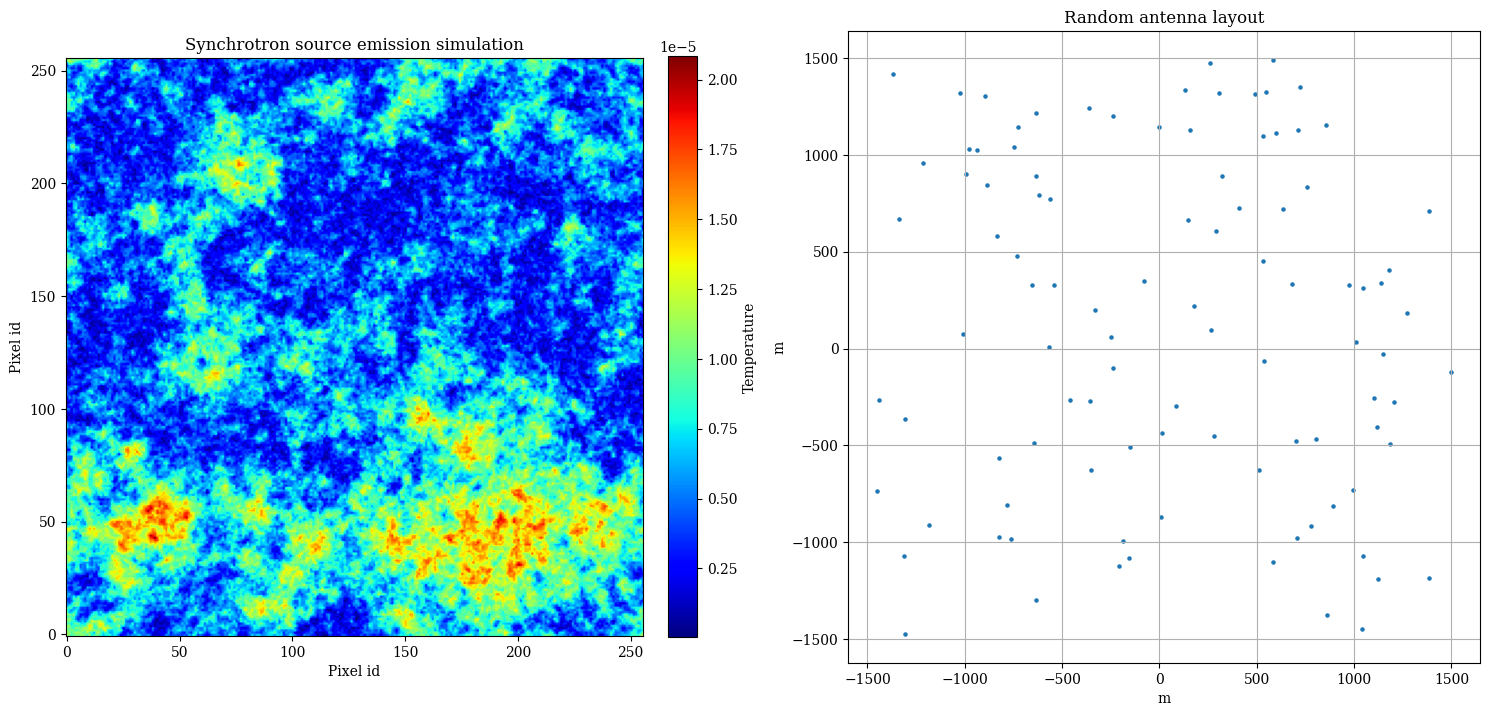

100%|██████████| 4950/4950 [00:20<00:00, 244.32it/s]


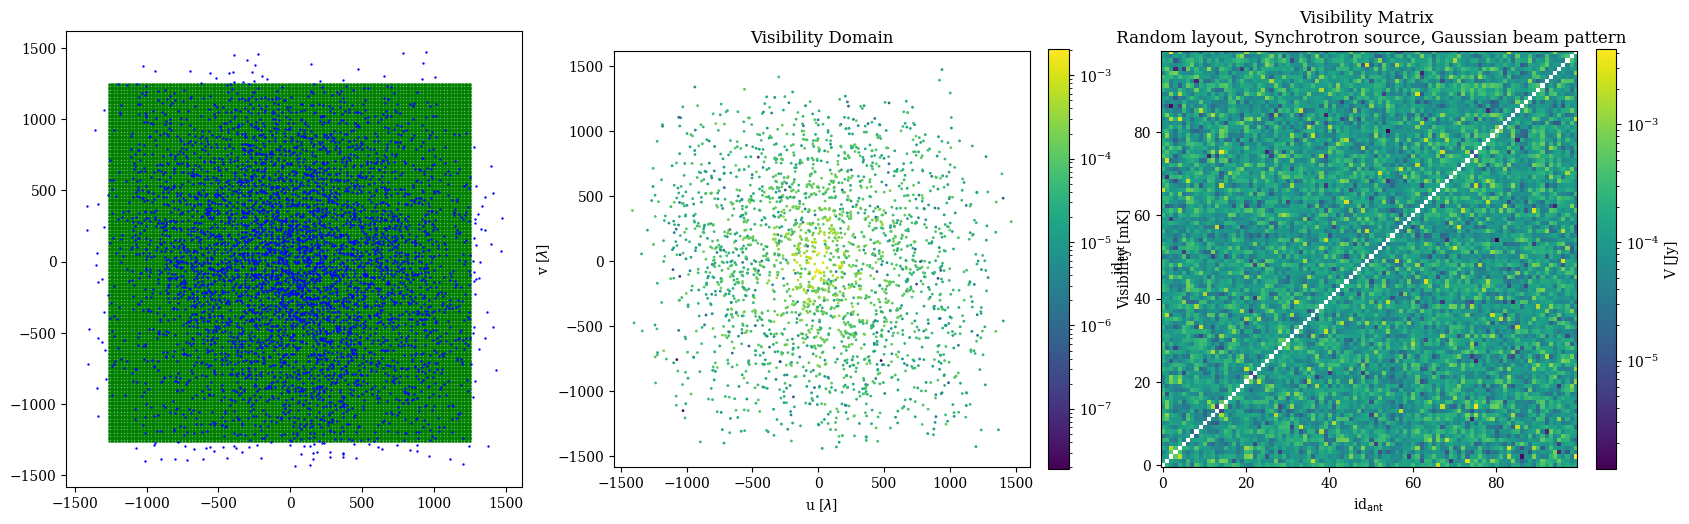

In [5]:
FoV= 5.8*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 256).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
# Generate the coordinates of the telescope layout
#xyz_random= ring_layout(60, 20, [1200, 900], [0, 900], 2024)
xyz_random= random_layout(10**2, [-1500., 1500.], 2024)
#***********************************************

# Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
com_dist= FoV.to('rad').value * t2c.cosmo.z_to_cdist(rshift)

# Gaussian and synchrotron sources, beam pattern
gaussian_source= gaussian_source_2d(l_coord, m_coord, [100.0, 100.0])
synchro_source, l= synchrotron_image(rshift, len(thet), com_dist, seed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord, D=45, z=rshift)

#***********************************************
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

im1 = axes[0].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[0].set_title("Synchrotron source emission simulation")
axes[0].set_ylabel('Pixel id')
axes[0].set_xlabel('Pixel id')
axes[0].set_box_aspect(1)
plt.colorbar(im1, label='Temperature', fraction=0.046, pad=0.04)

axes[1].scatter(xyz_random[:, 0], xyz_random[:, 1], s=5)
axes[1].set_xlabel("m")
axes[1].set_ylabel("m")
axes[1].set_title("Random antenna layout")
axes[1].grid()
axes[1].set_box_aspect(1)

plt.tight_layout()
plt.show()


visls_rndm, vismx_rndm, bls_rndm = visibility_matrix_func_new_method(xyz_random, thet, rshift, synchro_source, beam_pattern)

# Computing the frequency range of the FFT image
uu= np.fft.fftfreq(synchro_source.shape[0], np.diff(thet)[0])
vv= np.fft.fftfreq(synchro_source.shape[1], np.diff(thet)[0])
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)
u_freq, v_freq= np.meshgrid(uu, vv)

fig, axes= plt.subplots(1, 3, figsize=(20, 8))
axes[0].scatter(u_freq, v_freq, color='green', s=0.5)
axes[0].scatter(bls_rndm[:, 0], bls_rndm[:, 1], color='blue', s=0.5, label="Random layout")
axes[0].set_box_aspect(1)

im = axes[1].scatter(x=bls_rndm[:,0], y=bls_rndm[:,1], c=visls_rndm.real, s=1, norm=LogNorm())
axes[1].set_xlabel(r'u [$\lambda$]')
axes[1].set_ylabel(r'v [$\lambda$]')
axes[1].set_title('Visibility Domain')
axes[1].set_box_aspect(1)
plt.colorbar(im, ax= axes[1], label='Visibility [mK]', fraction=0.046, pad=0.04)

im2= axes[2].imshow(np.abs(vismx_rndm), origin='lower', cmap='viridis', norm=LogNorm())
axes[2].set_xlabel(r'id$_\mathrm{ant}$')
axes[2].set_ylabel(r'id$_\mathrm{ant}$')
axes[2].set_title('Visibility Matrix \n Random layout, Synchrotron source, Gaussian beam pattern')
axes[2].set_box_aspect(1)
plt.colorbar(im2, ax=axes[2], label='V [Jy]', fraction=0.046, pad=0.04)

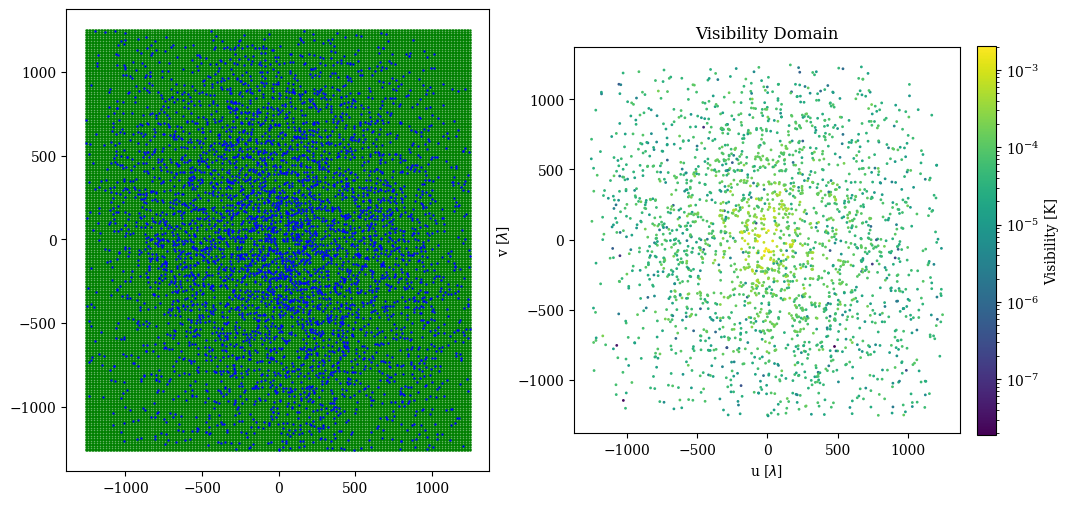

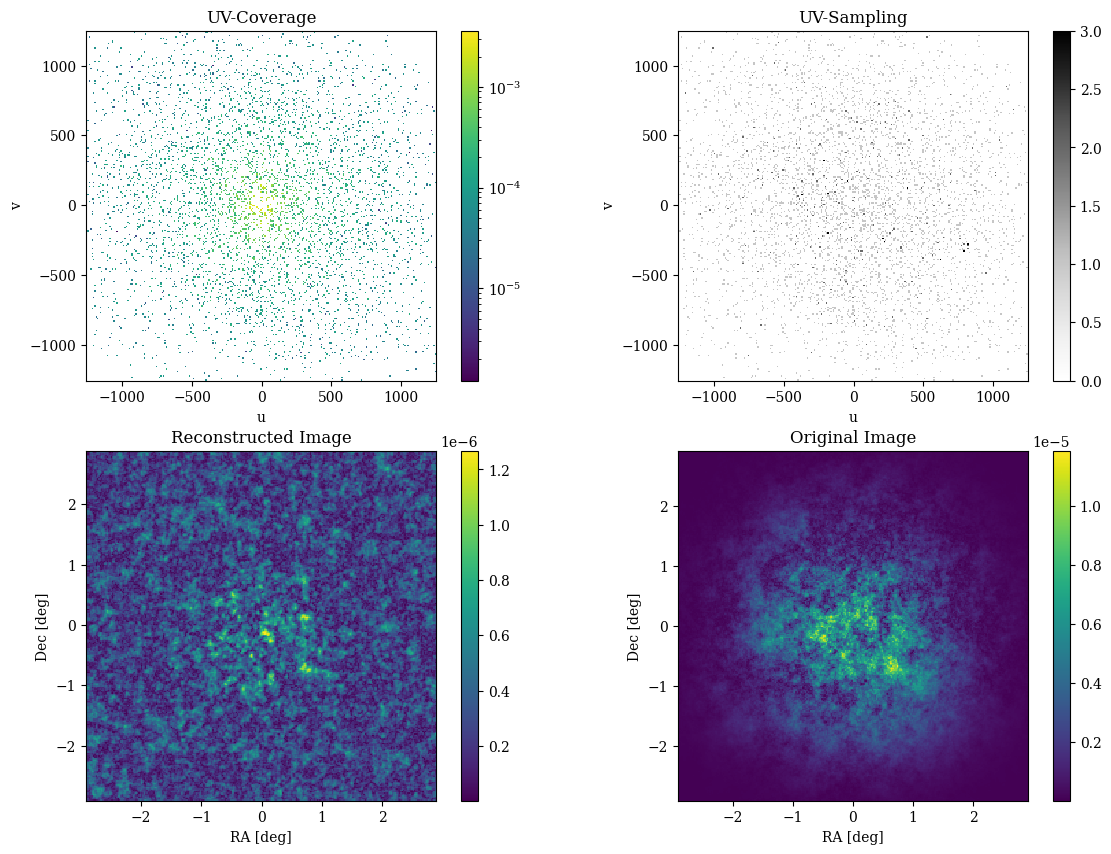

In [6]:
filter_bls, filter_vis = filter_baselines(bls_rndm, visls_rndm, u_freq, v_freq)

fig, axs= plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(u_freq, v_freq, color='green', s=0.5)
axs[0].scatter(filter_bls[:, 0], filter_bls[:, 1], color='blue', s=0.5)

im = axs[1].scatter(x=filter_bls[:,0], y=filter_bls[:,1], c=filter_vis.real, s=1, norm=LogNorm())
axs[1].set_xlabel(r'u [$\lambda$]')
axs[1].set_ylabel(r'v [$\lambda$]')
axs[1].set_title('Visibility Domain')
axs[1].set_box_aspect(1)
plt.colorbar(im, ax= axs[1], label='Visibility [K]', fraction=0.046, pad=0.04)

binned_rndm, uv_bin_rndm, uv_sampl_rndm, x_rndm_nobeam= image_reconstructing_func(filter_vis, filter_bls, uu[0], uu[-1], len(uu), 1)

fig, axs= plt.subplots(2, 2, figsize=(14, 10))

im0= axs[0,0].pcolormesh(uv_bin_rndm, uv_bin_rndm, np.abs(binned_rndm), norm=LogNorm(), cmap='viridis')
axs[0,0].set_title('UV-Coverage')
axs[0,0].set_xlabel('u')
axs[0,0].set_ylabel('v')
axs[0,0].set_box_aspect(1)
plt.colorbar(im0, ax=axs[0,0])

im1= axs[0,1].pcolormesh(uv_bin_rndm, uv_bin_rndm, uv_sampl_rndm, cmap='Greys')
axs[0,1].set_title('UV-Sampling')
axs[0,1].set_xlabel('u')
axs[0,1].set_ylabel('v')
axs[0,1].set_box_aspect(1)
plt.colorbar(im1, ax=axs[0,1])

synchro_reconstructed_rotflip_nobeam= np.flip(np.rot90(np.fft.fftshift(np.abs(np.fft.ifft2(binned_rndm))), k=-1), axis=1)
im2= axs[1,0].pcolormesh(np.rad2deg(x_rndm_nobeam*u.rad).value, np.rad2deg(x_rndm_nobeam*u.rad).value, 
                        synchro_reconstructed_rotflip_nobeam, cmap='viridis')
axs[1,0].set_title('Reconstructed Image')
axs[1,0].set_xlabel('RA [deg]')
axs[1,0].set_ylabel('Dec [deg]')
axs[1,0].set_box_aspect(1)
plt.colorbar(im2, ax=axs[1,0])

im3= axs[1,1].pcolormesh(np.rad2deg(l_coord*u.rad).value, np.rad2deg(m_coord*u.rad).value, synchro_source * beam_pattern, cmap='viridis')
axs[1,1].set_title('Original Image')
axs[1,1].set_xlabel('RA [deg]')
axs[1,1].set_ylabel('Dec [deg]')
axs[1,1].set_box_aspect(1)
plt.colorbar(im3, ax=axs[1,1])

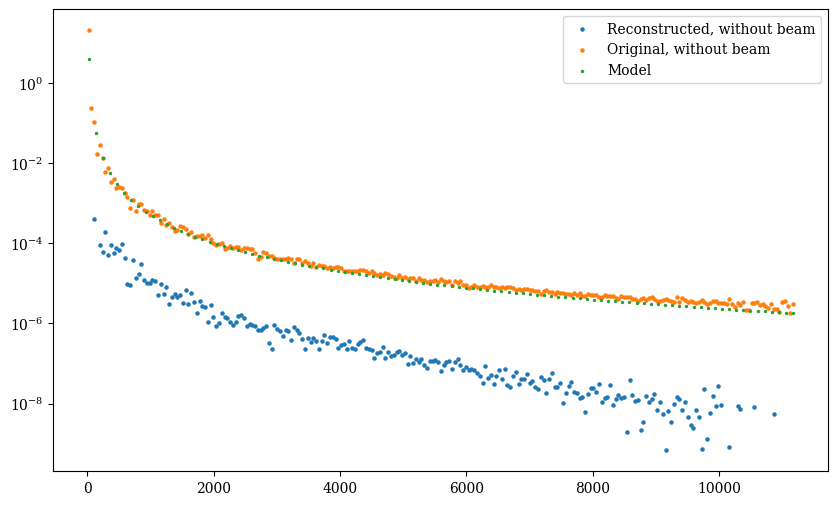

In [7]:
synchro_bin_centre, synchro_fft_binned = powerspec_1d(uv_bin_rndm, binned_rndm, FoV)

synchrosource_fft_nobeam= np.fft.fftshift(np.fft.fft2(synchro_source))
source_bin_centre_nobeam, source_fft_binned_nobeam= powerspec_1d(uu, synchrosource_fft_nobeam, FoV)

fig, axs= plt.subplots(1, 1, figsize=(10, 6))
axs.scatter(synchro_bin_centre, synchro_fft_binned, label='Reconstructed, without beam', s=5)
axs.scatter(source_bin_centre_nobeam, source_fft_binned_nobeam, label='Original, without beam', s=5)

ells= np.linspace(np.min(synchro_bin_centre), np.max(synchro_bin_centre), 100)
axs.scatter(ells, 5.13*1e-4 * (1000/ ells)**2.34, s=2, label= 'Model')
axs.legend()
axs.set_yscale('log')

In [8]:
bare_estimator_gmrt, ell_mean_gmrt= bare_estimator_func_v2(filter_bls, filter_vis, rshift, 45, 100, 'log')

Key:  1 ; Key legnth:  1 ; Combinations:  0.0
Key:  2 ; Key legnth:  0 ; Combinations:  0.0
Key:  3 ; Key legnth:  0 ; Combinations:  0.0
Key:  4 ; Key legnth:  1 ; Combinations:  0.0
Key:  5 ; Key legnth:  0 ; Combinations:  0.0
Key:  6 ; Key legnth:  0 ; Combinations:  0.0
Key:  7 ; Key legnth:  2 ; Combinations:  1.0
Key:  8 ; Key legnth:  0 ; Combinations:  0.0
Key:  9 ; Key legnth:  1 ; Combinations:  0.0
Key:  10 ; Key legnth:  1 ; Combinations:  0.0
Key:  11 ; Key legnth:  0 ; Combinations:  0.0
Key:  12 ; Key legnth:  2 ; Combinations:  1.0
Key:  13 ; Key legnth:  0 ; Combinations:  0.0
Key:  14 ; Key legnth:  0 ; Combinations:  0.0
Key:  15 ; Key legnth:  0 ; Combinations:  0.0
Key:  16 ; Key legnth:  0 ; Combinations:  0.0
Key:  17 ; Key legnth:  2 ; Combinations:  1.0
Key:  18 ; Key legnth:  1 ; Combinations:  0.0
Key:  19 ; Key legnth:  2 ; Combinations:  1.0
Key:  20 ; Key legnth:  3 ; Combinations:  3.0
Key:  21 ; Key legnth:  3 ; Combinations:  3.0
Key:  22 ; Key legnth:

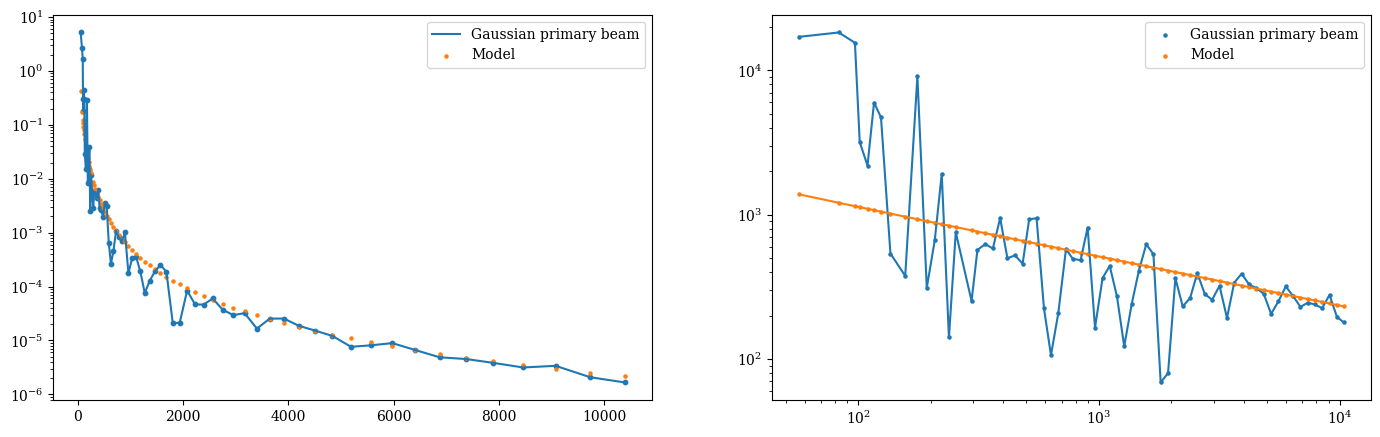

In [12]:
fig, axs= plt.subplots(1, 2, figsize=(17, 5))

axs[0].plot(ell_mean_gmrt, bare_estimator_gmrt, color= '#1f77b4', label= 'Gaussian primary beam')
axs[0].scatter(ell_mean_gmrt, bare_estimator_gmrt, s=10, color= '#1f77b4')
axs[0].scatter(ell_mean_gmrt, 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34, s=5, color= '#ff7f0e', label= 'Model')
axs[0].set_yscale('log')
axs[0].legend()

axs[1].plot(ell_mean_gmrt, ell_mean_gmrt * (ell_mean_gmrt +1) * bare_estimator_gmrt, color= '#1f77b4')
axs[1].scatter(ell_mean_gmrt, ell_mean_gmrt * (ell_mean_gmrt +1) * bare_estimator_gmrt, color= '#1f77b4', label= 'Gaussian primary beam', s=5)
axs[1].scatter(ell_mean_gmrt, ell_mean_gmrt*(ell_mean_gmrt+1)* 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34, s=5, color= '#ff7f0e', label= 'Model')
axs[1].plot(ell_mean_gmrt, ell_mean_gmrt*(ell_mean_gmrt+1)* 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34, color= '#ff7f0e')
axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].legend()

In [ ]:
bare_estimator_gmrt, ell_mean_gmrt= bare_estimator_func_v2(filter_bls, filter_vis, rshift, 45, 200, 'linear')

Key:  1 ; Key legnth:  13 ; Combinations:  78.0
Key:  2 ; Key legnth:  30 ; Combinations:  435.0
Key:  3 ; Key legnth:  37 ; Combinations:  666.0
Key:  4 ; Key legnth:  50 ; Combinations:  1225.0
Key:  5 ; Key legnth:  71 ; Combinations:  2485.0
Key:  6 ; Key legnth:  107 ; Combinations:  5671.0
Key:  7 ; Key legnth:  117 ; Combinations:  6786.0
Key:  8 ; Key legnth:  103 ; Combinations:  5253.0
Key:  9 ; Key legnth:  136 ; Combinations:  9180.0
Key:  10 ; Key legnth:  144 ; Combinations:  10296.0
Key:  11 ; Key legnth:  169 ; Combinations:  14196.0
Key:  12 ; Key legnth:  210 ; Combinations:  21945.0
Key:  13 ; Key legnth:  191 ; Combinations:  18145.0
Key:  14 ; Key legnth:  241 ; Combinations:  28920.0
Key:  15 ; Key legnth:  239 ; Combinations:  28441.0
Key:  16 ; Key legnth:  295 ; Combinations:  43365.0
Key:  17 ; Key legnth:  256 ; Combinations:  32640.0
Key:  18 ; Key legnth:  294 ; Combinations:  43071.0
Key:  19 ; Key legnth:  281 ; Combinations:  39340.0
Key:  20 ; Key legnt

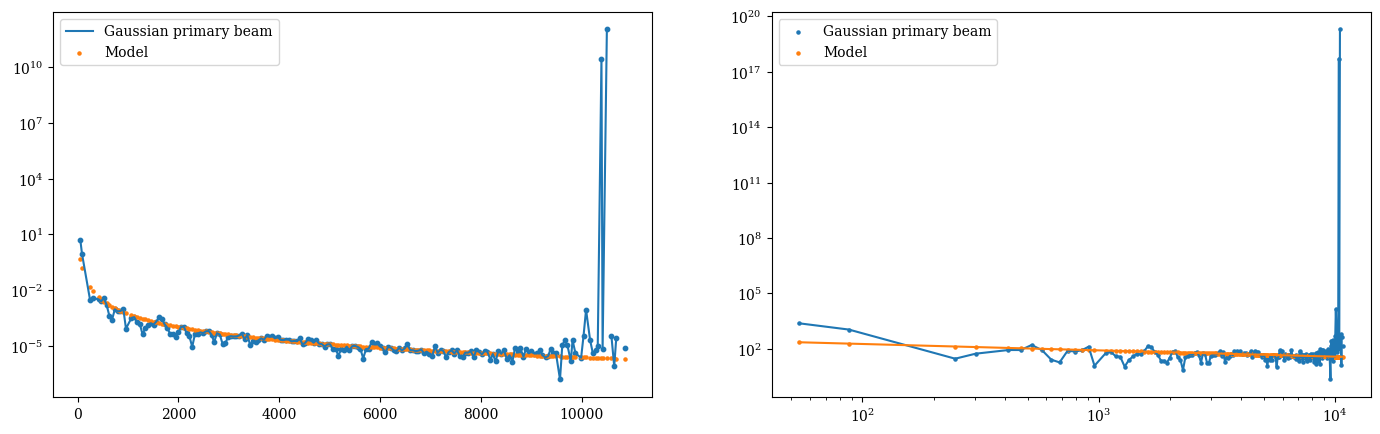

In [9]:
fig, axs= plt.subplots(1, 2, figsize=(17, 5))

axs[0].plot(ell_mean_gmrt, bare_estimator_gmrt, color= '#1f77b4', label= 'Gaussian primary beam')
axs[0].scatter(ell_mean_gmrt, bare_estimator_gmrt, s=10, color= '#1f77b4')
axs[0].scatter(ell_mean_gmrt, 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34, s=5, color= '#ff7f0e', label= 'Model')
axs[0].set_yscale('log')
axs[0].legend()

axs[1].plot(ell_mean_gmrt, ell_mean_gmrt * (ell_mean_gmrt +1) * bare_estimator_gmrt / (2*np.pi)
            , color= '#1f77b4')
axs[1].scatter(ell_mean_gmrt, ell_mean_gmrt * (ell_mean_gmrt +1) * bare_estimator_gmrt / (2*np.pi), color= '#1f77b4', label= 'Gaussian primary beam', s=5)
axs[1].scatter(ell_mean_gmrt, ell_mean_gmrt*(ell_mean_gmrt+1)* 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34 / (2*np.pi), s=5, color= '#ff7f0e', label= 'Model')
axs[1].plot(ell_mean_gmrt, ell_mean_gmrt*(ell_mean_gmrt+1)* 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34 / (2*np.pi), color= '#ff7f0e')
axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].legend()

***
## __Bare estimator for the GMRT layout.__

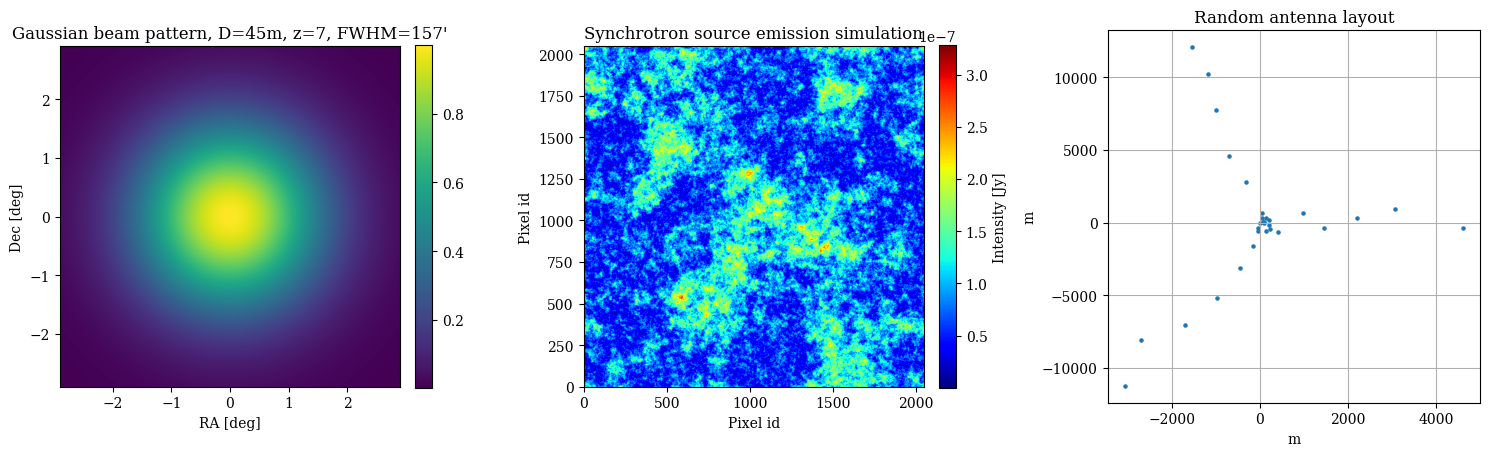

100%|██████████| 435/435 [04:46<00:00,  1.52it/s]


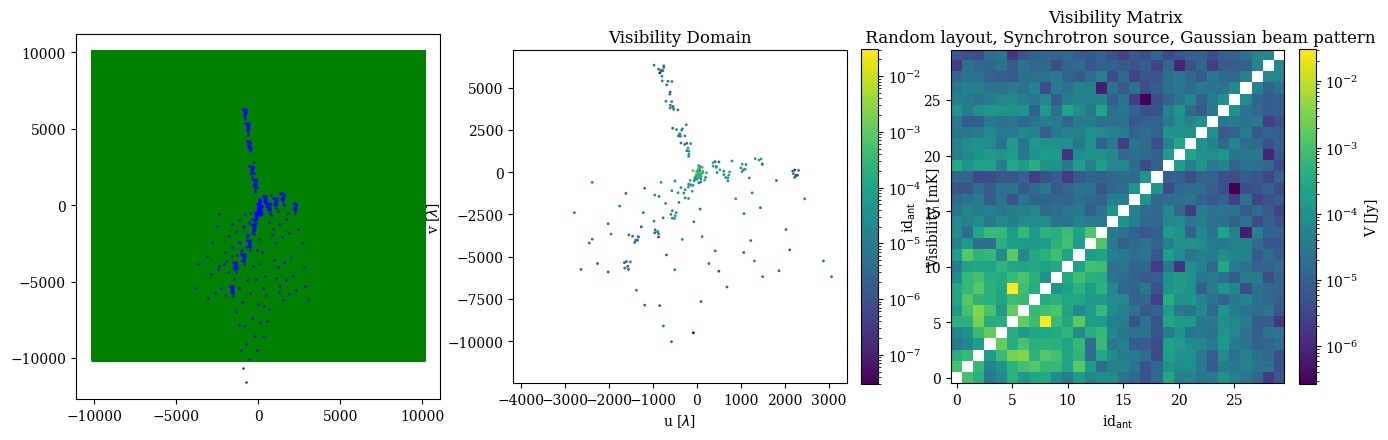

In [9]:
FoV= 5.8*u.deg

# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, 2048).to('rad').value

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet)
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

#***********************************************
# Generate the coordinates of the telescope layout
gmrt_layout = np.loadtxt('gmrt_layout.txt')
#Remove the z-coordinates from the layout:
gmrt_layout= gmrt_layout[:,:-1]
#***********************************************

# Angular diameter distance (in Mpc) for a specified redshift and FoV in deg
rshift=8.52
com_dist= FoV.to('rad').value * t2c.cosmo.z_to_cdist(rshift)

# Gaussian and synchrotron sources, beam pattern
synchro_source, l= synchrotron_image(z=rshift, ncells=len(thet), boxsize=com_dist, seed=2024)
beam_pattern= telescope_beam_pattern(l_coord, m_coord, D=45, z=rshift)

#***********************************************
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

im0 = axes[0].pcolormesh(np.rad2deg(l_coord), np.rad2deg(m_coord), beam_pattern, cmap='viridis')
axes[0].set_ylabel('Dec [deg]')
axes[0].set_xlabel('RA [deg]')
axes[0].set_title("Gaussian beam pattern, D=45m, z=7, FWHM=157'")
axes[0].set_box_aspect(1)
plt.colorbar(im0, fraction=0.046, pad=0.04)

im1 = axes[1].imshow(synchro_source, cmap='jet', origin= 'lower')
axes[1].set_title("Synchrotron source emission simulation")
axes[1].set_ylabel('Pixel id')
axes[1].set_xlabel('Pixel id')
axes[1].set_box_aspect(1)
plt.colorbar(im1, label='Intensity [Jy]', fraction=0.046, pad=0.04)

axes[2].scatter(gmrt_layout[:, 0], gmrt_layout[:, 1], s=5)
axes[2].set_xlabel("m")
axes[2].set_ylabel("m")
axes[2].set_title("Random antenna layout")
axes[2].grid()
axes[2].set_box_aspect(1)

plt.tight_layout()
plt.show()

visls_gmrt_sy, vismx_gmrt_sy, bls_gmrt_sy = visibility_matrix_func_new_method(gmrt_layout, thet, rshift, synchro_source, beam_pattern)

# Computing the frequency range of the FFT image
uu= np.fft.fftfreq(synchro_source.shape[0], np.diff(thet)[0])
vv= np.fft.fftfreq(synchro_source.shape[1], np.diff(thet)[0])
uu= np.fft.fftshift(uu)
vv= np.fft.fftshift(vv)
u_freq, v_freq= np.meshgrid(uu, vv)

fig, axes= plt.subplots(1, 3, figsize=(16, 8))
axes[0].scatter(u_freq, v_freq, color='green', s=0.5)
axes[0].scatter(bls_gmrt_sy[:, 0], bls_gmrt_sy[:, 1], color='blue', s=0.5, label="Random layout")
axes[0].set_box_aspect(1)

im = axes[1].scatter(x=bls_gmrt_sy[:,0], y=bls_gmrt_sy[:,1], c=visls_gmrt_sy.real, s=1, norm=LogNorm())
axes[1].set_xlabel(r'u [$\lambda$]')
axes[1].set_ylabel(r'v [$\lambda$]')
axes[1].set_title('Visibility Domain')
axes[1].set_box_aspect(1)
plt.colorbar(im, ax= axes[1], label='Visibility [mK]', fraction=0.046, pad=0.04)

im2= axes[2].imshow(np.abs(vismx_gmrt_sy), origin='lower', cmap='viridis', norm=LogNorm())
axes[2].set_xlabel(r'id$_\mathrm{ant}$')
axes[2].set_ylabel(r'id$_\mathrm{ant}$')
axes[2].set_title('Visibility Matrix \n Random layout, Synchrotron source, Gaussian beam pattern')
axes[2].set_box_aspect(1)
plt.colorbar(im2, ax=axes[2], label='V [Jy]', fraction=0.046, pad=0.04)

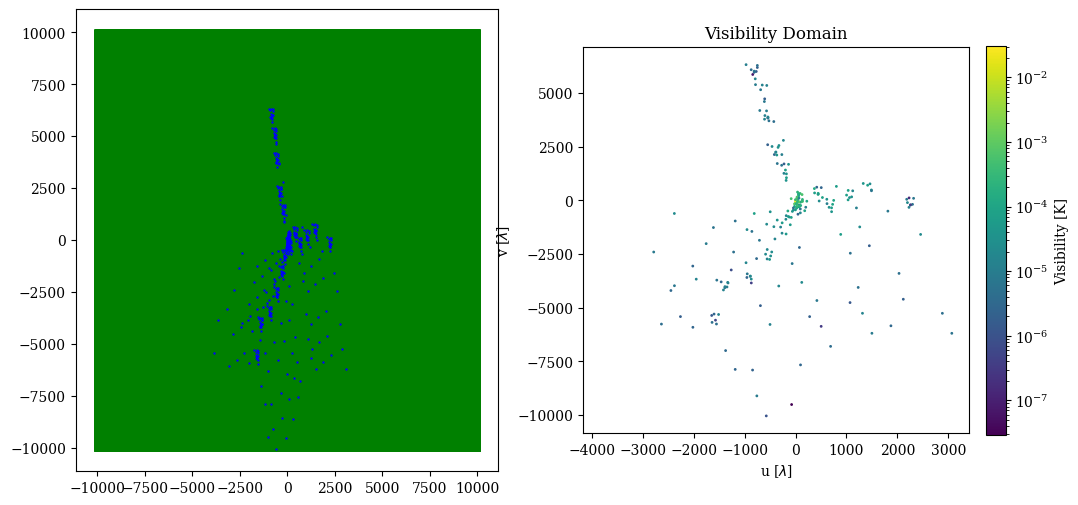

In [12]:
bls_gmrt_sy_filter, visls_gmrt_sy_filter = filter_baselines(bls_gmrt_sy, visls_gmrt_sy, u_freq, v_freq)

fig, axs= plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(u_freq, v_freq, color='green', s=0.5)
axs[0].scatter(bls_gmrt_sy_filter[:, 0], bls_gmrt_sy_filter[:, 1], color='blue', s=0.5)

im = axs[1].scatter(x=bls_gmrt_sy_filter[:,0], y=bls_gmrt_sy_filter[:,1], c=visls_gmrt_sy_filter.real, s=1, norm=LogNorm())
axs[1].set_xlabel(r'u [$\lambda$]')
axs[1].set_ylabel(r'v [$\lambda$]')
axs[1].set_title('Visibility Domain')
axs[1].set_box_aspect(1)
plt.colorbar(im, ax= axs[1], label='Visibility [K]', fraction=0.046, pad=0.04)

In [13]:
bare_estimator_gmrt, ell_mean_gmrt= bare_estimator_func_v2(bls_gmrt_sy_filter, visls_gmrt_sy_filter, rshift, 45, 20, 'log')

Key:  1 ; Key legnth:  1 ; Combinations:  0.0
Key:  2 ; Key legnth:  0 ; Combinations:  0.0
Key:  3 ; Key legnth:  1 ; Combinations:  0.0
Key:  4 ; Key legnth:  3 ; Combinations:  3.0
Key:  5 ; Key legnth:  3 ; Combinations:  3.0
Key:  6 ; Key legnth:  6 ; Combinations:  15.0
Key:  7 ; Key legnth:  15 ; Combinations:  105.0
Key:  8 ; Key legnth:  12 ; Combinations:  66.0
Key:  9 ; Key legnth:  17 ; Combinations:  136.0
Key:  10 ; Key legnth:  23 ; Combinations:  253.0
Key:  11 ; Key legnth:  26 ; Combinations:  325.0
Key:  12 ; Key legnth:  27 ; Combinations:  351.0
Key:  13 ; Key legnth:  29 ; Combinations:  406.0
Key:  14 ; Key legnth:  49 ; Combinations:  1176.0
Key:  15 ; Key legnth:  44 ; Combinations:  946.0
Key:  16 ; Key legnth:  35 ; Combinations:  595.0
Key:  17 ; Key legnth:  66 ; Combinations:  2145.0
Key:  18 ; Key legnth:  64 ; Combinations:  2016.0
Key:  19 ; Key legnth:  11 ; Combinations:  55.0
Key:  20 ; Key legnth:  1 ; Combinations:  0.0
Key:  4 ; Key legnth:  3 ; C

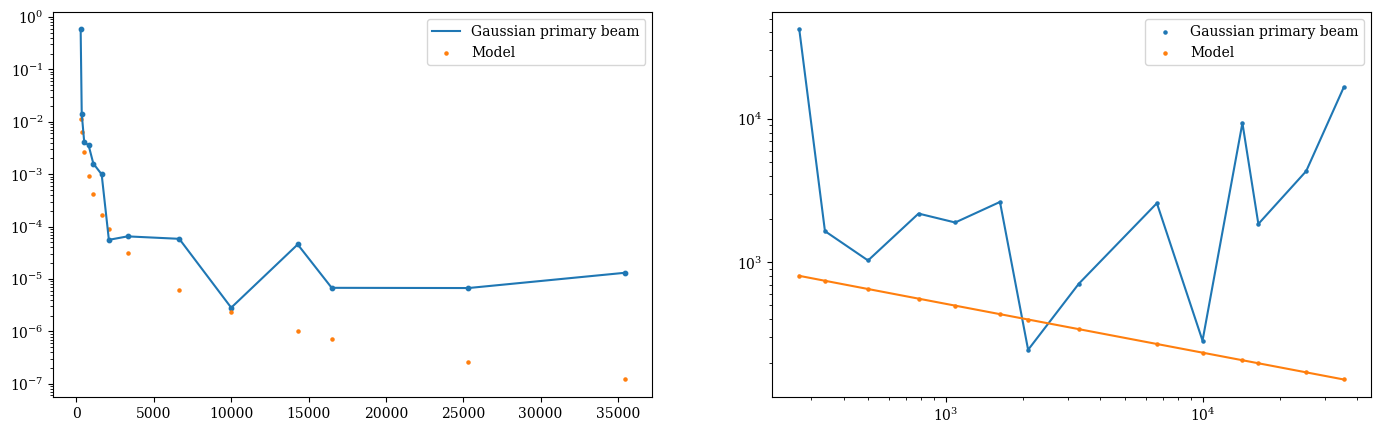

In [14]:
fig, axs= plt.subplots(1, 2, figsize=(17, 5))

axs[0].plot(ell_mean_gmrt, bare_estimator_gmrt, color= '#1f77b4', label= 'Gaussian primary beam')
axs[0].scatter(ell_mean_gmrt, bare_estimator_gmrt, s=10, color= '#1f77b4')
axs[0].scatter(ell_mean_gmrt, 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34, s=5, color= '#ff7f0e', label= 'Model')
axs[0].set_yscale('log')
axs[0].legend()

axs[1].plot(ell_mean_gmrt, ell_mean_gmrt * (ell_mean_gmrt +1) * bare_estimator_gmrt, color= '#1f77b4')
axs[1].scatter(ell_mean_gmrt, ell_mean_gmrt * (ell_mean_gmrt +1) * bare_estimator_gmrt, color= '#1f77b4', label= 'Gaussian primary beam', s=5)
axs[1].scatter(ell_mean_gmrt, ell_mean_gmrt*(ell_mean_gmrt+1)* 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34, s=5, color= '#ff7f0e', label= 'Model')
axs[1].plot(ell_mean_gmrt, ell_mean_gmrt*(ell_mean_gmrt+1)* 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34, color= '#ff7f0e')
axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].legend()

In [63]:
bare_estimator_gmrt, ell_mean_gmrt, variances_squared= bare_estimator_func_v3(bls_gmrt_sy_filter, visls_gmrt_sy_filter, rshift, 45, 20, 'log')

Key:  1 ; Key legnth:  1 ; Combinations:  0.0
Key:  2 ; Key legnth:  0 ; Combinations:  0.0
Key:  3 ; Key legnth:  1 ; Combinations:  0.0
Key:  4 ; Key legnth:  3 ; Combinations:  3.0
Key:  5 ; Key legnth:  3 ; Combinations:  3.0
Key:  6 ; Key legnth:  6 ; Combinations:  15.0
Key:  7 ; Key legnth:  15 ; Combinations:  105.0
Key:  8 ; Key legnth:  12 ; Combinations:  66.0
Key:  9 ; Key legnth:  17 ; Combinations:  136.0
Key:  10 ; Key legnth:  23 ; Combinations:  253.0
Key:  11 ; Key legnth:  26 ; Combinations:  325.0
Key:  12 ; Key legnth:  27 ; Combinations:  351.0
Key:  13 ; Key legnth:  29 ; Combinations:  406.0
Key:  14 ; Key legnth:  49 ; Combinations:  1176.0
Key:  15 ; Key legnth:  44 ; Combinations:  946.0
Key:  16 ; Key legnth:  35 ; Combinations:  595.0
Key:  17 ; Key legnth:  66 ; Combinations:  2145.0
Key:  18 ; Key legnth:  64 ; Combinations:  2016.0
Key:  19 ; Key legnth:  11 ; Combinations:  55.0
Key:  20 ; Key legnth:  1 ; Combinations:  0.0
Key:  4 ; Key legnth:  3 ; C

In [64]:
print(variances_squared)

[1.22665697e-04 4.17740593e-05 6.63247832e-06 8.35624854e-07
 1.73527670e-07 2.68233283e-08 8.46187727e-09 9.46460654e-10
 3.56733483e-11 5.08381014e-12 1.03167038e-12 5.28301826e-13
 7.11953064e-14 1.53352092e-14            nan]


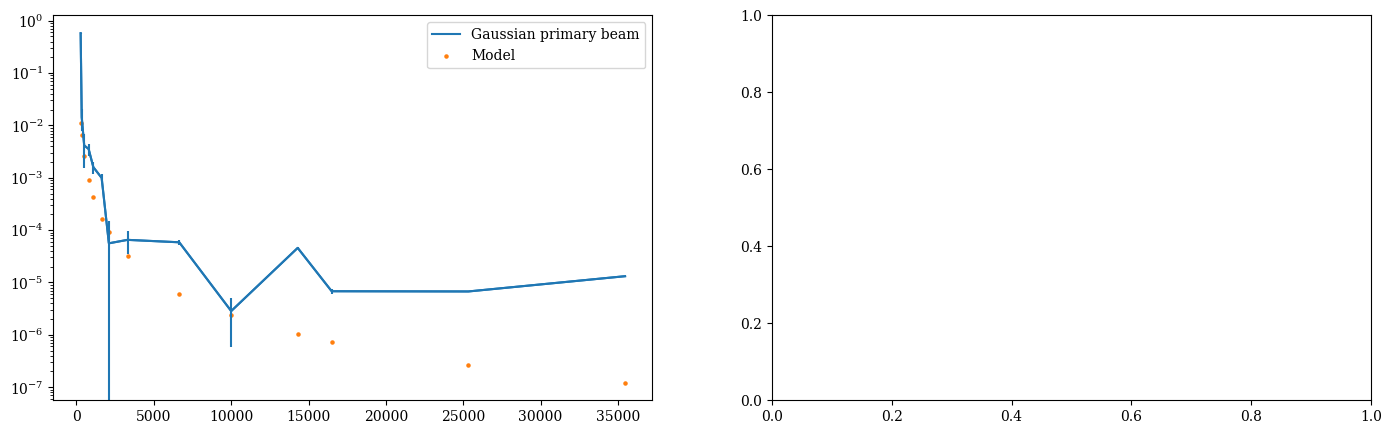

In [65]:
fig, axs= plt.subplots(1, 2, figsize=(17, 5))

axs[0].plot(ell_mean_gmrt, bare_estimator_gmrt, color= '#1f77b4', label= 'Gaussian primary beam')
axs[0].errorbar(ell_mean_gmrt, bare_estimator_gmrt, np.sqrt(variances_squared), color= '#1f77b4')

axs[0].scatter(ell_mean_gmrt, 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34, s=5, color= '#ff7f0e', label= 'Model')
axs[0].set_yscale('log')
axs[0].legend()

# axs[1].plot(ell_mean_gmrt, ell_mean_gmrt * (ell_mean_gmrt +1) * bare_estimator_gmrt, color= '#1f77b4')
# axs[1].scatter(ell_mean_gmrt, ell_mean_gmrt * (ell_mean_gmrt +1) * bare_estimator_gmrt, color= '#1f77b4', label= 'Gaussian primary beam', s=5)
# axs[1].scatter(ell_mean_gmrt, ell_mean_gmrt*(ell_mean_gmrt+1)* 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34, s=5, color= '#ff7f0e', label= 'Model')
# axs[1].plot(ell_mean_gmrt, ell_mean_gmrt*(ell_mean_gmrt+1)* 5.13*1e-4 * (1000/ ell_mean_gmrt)**2.34, color= '#ff7f0e')
# axs[1].set_yscale('log')
# axs[1].set_xscale('log')
# axs[1].legend()